**E-Commerce Purchase Prediction using Machine Learning**

**Problem Statement**

This project aims to predict whether a user will make a purchase based on their behavior on an e-commerce platform.

In [ ]:
#Load dataset
import pandas as pd

data = pd.read_csv("ecommerce.csv")
data.head()

,user_id,age,gender,device_type,time_on_site,pages_viewed,previous_purchases,cart_items,discount_seen,ad_clicked,returning_user,avg_session_time,bounce_rate,purchase
0,1.0,56.0,Female,Desktop,12.90,8.0,13.0,1.0,1.0,NaN,0.0,6.97,28.18,1.0
1,2.0,46.0,Male,Mobile,15.63,9.0,4.0,6.0,1.0,1.0,1.0,19.17,86.73,1.0
2,3.0,32.0,Female,NaN,11.64,12.0,11.0,0.0,0.0,0.0,1.0,8.87,83.09,1.0
3,4.0,25.0,Female,Mobile,22.71,5.0,10.0,1.0,0.0,0.0,1.0,NaN,79.03,1.0
4,5.0,38.0,Female,Mobile,26.35,9.0,12.0,4.0,1.0,0.0,0.0,18.15,55.35,1.0


In [ ]:
#Check data
data.info()
data.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   user_id             7840 non-null   float64
 1   age                 7840 non-null   float64
 2   gender              7840 non-null   object 
 3   device_type         7840 non-null   object 
 4   time_on_site        7840 non-null   float64
 5   pages_viewed        7840 non-null   float64
 6   previous_purchases  7840 non-null   float64
 7   cart_items          7840 non-null   float64
 8   discount_seen       7840 non-null   float64
 9   ad_clicked          7840 non-null   float64
 10  returning_user      7840 non-null   float64
 11  avg_session_time    7840 non-null   float64
 12  bounce_rate         7840 non-null   float64
 13  purchase            7840 non-null   float64
dtypes: float64(12), object(2)
memory usage: 875.1+ KB


,0
user_id,160
age,160
gender,160
device_type,160
time_on_site,160
pages_viewed,160
previous_purchases,160
cart_items,160
discount_seen,160
ad_clicked,160


In [ ]:
#Data Preprocessing
#(Fill missing values)
data.fillna(method='ffill', inplace=True)

/tmp/ipykernel_1826/2866031220.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data.fillna(method='ffill', inplace=True)


In [ ]:
#(Convert categorical to numeric)
data = pd.get_dummies(data, drop_first=True)

In [ ]:
#Define features & target
X = data.drop(['user_id', 'purchase'], axis=1)
y = data['purchase']

In [ ]:
#Train-Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [ ]:
#Train Model
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
#Prediction
y_pred = model.predict(X_test)

In [ ]:
#Accuracy
from sklearn.metrics import accuracy_score, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.99625
Confusion Matrix:
 [[   1    6]
 [   0 1593]]


In [ ]:
#Fixing to improve quality
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [ ]:
#Accuracy
y_pred = model.predict(X_test)

from sklearn.metrics import accuracy_score, confusion_matrix
print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.98125
[[   5    2]
 [  28 1565]]


In [ ]:
#Classification Report
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.15      0.71      0.25         7
         1.0       1.00      0.98      0.99      1593

    accuracy                           0.98      1600
   macro avg       0.58      0.85      0.62      1600
weighted avg       1.00      0.98      0.99      1600



The model performs very well for predicting purchase behavior (class 1), achieving high precision and recall. However, due to class imbalance, the performance for non-purchase (class 0) is lower. Despite this, the model is effective for identifying potential buyers, which is valuable for e-commerce applications.

**Data Visualization**

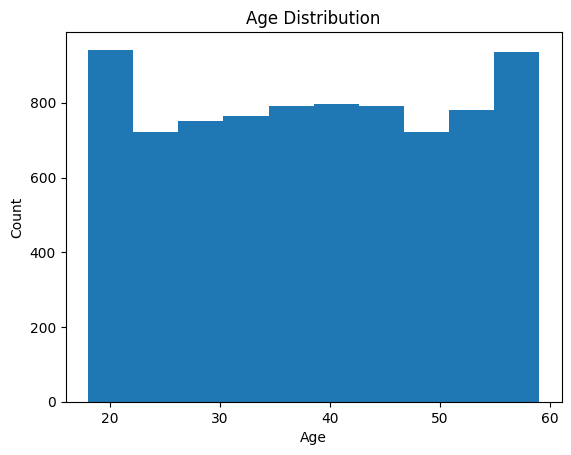

In [ ]:
#Age Distribution
import matplotlib.pyplot as plt

plt.hist(data['age'])
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

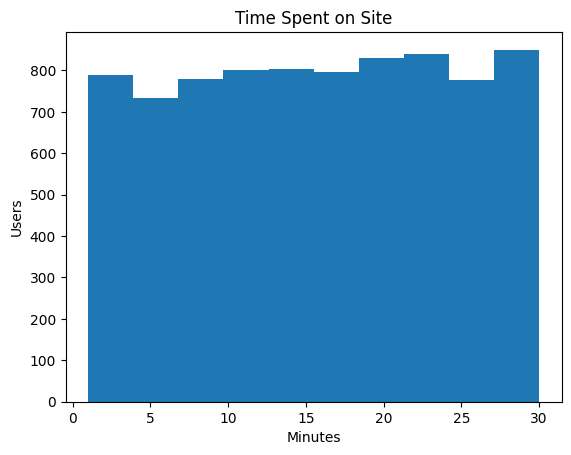

In [ ]:
#Time Spent on Site
plt.hist(data['time_on_site'])
plt.title("Time Spent on Site")
plt.xlabel("Minutes")
plt.ylabel("Users")
plt.show()

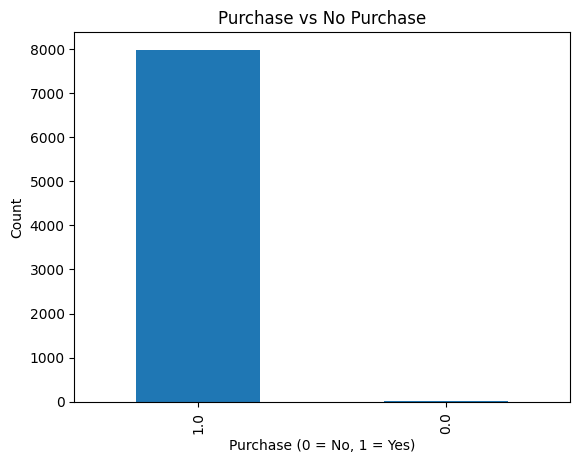

In [ ]:
#Purchase Count
data['purchase'].value_counts().plot(kind='bar')
plt.title("Purchase vs No Purchase")
plt.xlabel("Purchase (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

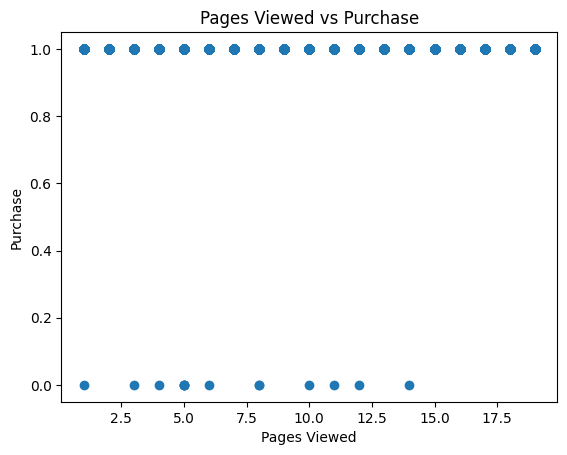

In [ ]:
#Pages Viewed vs Purchase
plt.scatter(data['pages_viewed'], data['purchase'])
plt.title("Pages Viewed vs Purchase")
plt.xlabel("Pages Viewed")
plt.ylabel("Purchase")
plt.show()

The visualizations show user behavior patterns such as time spent on site, pages viewed, and purchase distribution. The purchase distribution graph indicates class imbalance in the dataset. These insights help in understanding the data before applying machine learning models.